# 02 · Bernoulli & Binomial Dağılımları
**Probability Lab** · Discrete Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Veri biliminin en temel iki kesikli dağılımını —  
> **Bernoulli** (tek deneme) ve **Binomial** (n deneme) — sıfırdan anlayacağız.  
> Coin flip'ten A/B testine, hasta tanısından kalite kontrolüne kadar her yerde bunlar var.

**Önkoşul:** PMF / CDF kavramları (Notebook 01)  
**Kullanılan araçlar:** Python (scipy, matplotlib, seaborn), R (base), SQL (DuckDB)

---
## 1 · Bernoulli Dağılımı

### Sezgi: "Ya olur ya olmaz" deneyleri

Hayatın en temel sorusu bazen sadece iki cevaba sahiptir:

| Deney | Başarı (1) | Başarızlık (0) |
|---|---|---|
| Para atmak | Yazı | Tura |
| E-posta açmak | Açıldı | Açılmadı |
| İlaç vermek | İyileşti | İyileşmedi |
| Bağlantı kurmak | Bağlandı | Bağlanamadı |

Bu tür deneylere **Bernoulli deneyi** denir. Sonucu modelleyen dağılım **Bernoulli dağılımıdır**.

### Tanım

$X \sim \text{Bernoulli}(p)$ demek:
- $X$ ya 0 ya 1 değeri alır
- $p$ = başarı olasılığı $(0 \leq p \leq 1)$
- $1-p$ = başarısızlık olasılığı (bazen $q = 1-p$ yazılır)

### PMF

$$P(X = x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$$

Açık hali:
$$P(X = 1) = p \qquad P(X = 0) = 1-p$$

### Beklenti ve Varyans

$$E[X] = p$$
$$\text{Var}(X) = p(1-p)$$

> **Sezgi:** $E[X] = p$ gayet mantıklı — defalarca atarsak ortalama *p* kadar yazı çıkar.  
> Varyans $p(1-p)$ ise $p = 0.5$'te maksimum olur — "en belirsiz" durum tam ortadaki şans.

### Özel Durum Tablosu

| $p$ | $E[X]$ | $\text{Var}(X)$ | Yorum |
|---|---|---|---|
| 0.0 | 0.0 | 0.0 | Hiç başarı yok, kesin bilgi var |
| 0.5 | 0.5 | 0.25 | Maksimum belirsizlik |
| 1.0 | 1.0 | 0.0 | Her zaman başarı, kesin bilgi var |
| 0.3 | 0.3 | 0.21 | %30 başarı ihtimali |

---
## 2 · Binomial Dağılımı

### Sezgi: "n bağımsız Bernoulli denemesi"

Bernoulli tek bir "ya olur ya olmaz" sorusuydu.  
**Binomial ise aynı soruyu $n$ kez sorar** ve toplamda kaç kez "evet" çıktığını sayar.

> Örnek: 20 müşteriye e-posta gönderdik, her biri %30 ihtimalle açar.  
> Kaç tanesi açar? → Bu Binomial sorusudur.

### Tanım

$X \sim \text{Binomial}(n, p)$ demek:
- $n$ bağımsız ve özdeş Bernoulli denemesi
- Her denemede başarı olasılığı $p$
- $X$ = toplam başarı sayısı → $\{0, 1, 2, \ldots, n\}$ değerlerini alabilir

### PMF

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k \in \{0, 1, \ldots, n\}$$

Burada $\binom{n}{k}$ **binom katsayısıdır** (kombinasyon):

$$\binom{n}{k} = \frac{n!}{k!(n-k)!}$$

Bu formülün üç parçası vardır:

| Parça | Ne anlama geliyor? | Örnek (n=5, k=2) |
|---|---|---|
| $\binom{n}{k}$ | $n$ denemeden $k$ tane "başarılı" seçmenin kaç yolu var? | $\binom{5}{2} = 10$ |
| $p^k$ | $k$ tane başarının olasılığı | $0.3^2 = 0.09$ |
| $(1-p)^{n-k}$ | Geri kalan $n-k$ tane başarısızlığın olasılığı | $0.7^3 = 0.343$ |

$P(X=2) = 10 \times 0.09 \times 0.343 = 0.3087$

### Beklenti ve Varyans

$$E[X] = np$$
$$\text{Var}(X) = np(1-p)$$

> **Sezgi:** 100 e-posta, %30 açılma → ortalama $100 \times 0.3 = 30$ açılır.  
> Varyans $= 100 \times 0.3 \times 0.7 = 21$ → standart sapma $\approx 4.6$.

### Bernoulli ile İlişki

$$X \sim \text{Binomial}(n, p) \iff X = X_1 + X_2 + \ldots + X_n$$

Burada $X_1, X_2, \ldots, X_n$ bağımsız $\text{Bernoulli}(p)$ değişkenleridir.  
**Binomial = $n$ tane Bernoulli'nin toplamı.**

| | Bernoulli | Binomial |
|---|---|---|
| Parametre | $p$ | $n, p$ |
| Değer aralığı | $\{0, 1\}$ | $\{0, 1, \ldots, n\}$ |
| $E[X]$ | $p$ | $np$ |
| $\text{Var}(X)$ | $p(1-p)$ | $np(1-p)$ |
| Özel durum | — | $n=1$ → Bernoulli |

---
## 3 · Normal Yaklaşımı (Büyük n için)

$n$ büyüdükçe Binomial dağılımı **Normal dağılıma yaklaşır**.  
Bu, Merkezi Limit Teoremi'nin (CLT) bir sonucudur — ilerleyen bölümde detaylı göreceğiz.

Pratik kural: $np \geq 5$ ve $n(1-p) \geq 5$ ise yaklaşım iyidir.

$$X \sim \text{Binomial}(n, p) \approx N(np, np(1-p)) \quad \text{(büyük } n \text{ için)}$$

**Neden önemli?**  
- Büyük $n$'de Binomial hesabı ağır → Normal ile yaklaşım hız kazandırır
- A/B testlerindeki istatistiksel anlamlılık testleri bu yaklaşıma dayanır
- Merkezi Limit Teoremi için somut sezgi sunar

### Süreklilik Düzeltmesi (Continuity Correction)

Kesikli → Sürekli geçişte küçük bir düzeltme yapılır:

$$P(X = k) \approx P\left(k - 0.5 \leq Z \leq k + 0.5\right)$$

Bu düzeltme özellikle küçük-orta $n$ değerlerinde doğruluğu artırır.

---
## 4 · Ne Zaman Hangisini Kullanırım?

| Soru | Dağılım | Örnek |
|---|---|---|
| Bu e-posta açılacak mı? | Bernoulli($p$) | Tek bir müşteri |
| 100 e-postanın kaçı açılır? | Binomial($100, p$) | Tüm kampanya |
| En az 30'u açılma olasılığı? | Binomial CDF | $P(X \geq 30)$ |
| Tıklama oranı nedir? | MLE ile $\hat{p}$ tahmini | $\hat{p} = k/n$ |

**Binomial'in varsayımları (ihlal edilirse model bozulur):**
1. Her deneme **bağımsız** olmalı (bir kullanıcının açması diğerini etkilemez)
2. Her denemede **aynı $p$** geçerli olmalı (tüm e-postalar aynı)
3. Deneme sayısı $n$ **sabit** olmalı

> **Uyarı:** Gerçek hayatta bu varsayımlar sıklıkla ihlal edilir.  
> Örneğin kullanıcılar birbirini etkiliyor olabilir (sosyal ağ etkisi) → Binomial değil.

---
# 🐍 Python Uygulaması

4 adımda ilerleyeceğiz:
1. **Bernoulli** — PMF görselleştirme + coin flip simülasyonu
2. **Binomial** — PMF şekli ($n, p$ değişince ne olur?)
3. **Binomial CDF** — olasılık soruları cevaplandırma
4. **Gerçek veri** — Titanic'te hayatta kalma → Binomial fit
5. **Normal yaklaşımı** — $n$ büyüyünce Binomial nasıl değişir?

In [1]:
import numpy as np
import scipy.stats as stats
from scipy.special import comb   # binom katsayisi icin
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12
print('Hazir ✓')


Hazir ✓


---
### 🎲 Python 1 — Bernoulli: PMF + Coin Flip Simülasyonu

**Ne yapıyoruz?**  
Farklı $p$ değerleri için Bernoulli PMF'ini çiziyor,  
ardından gerçek coin flip deneyi yapıp LLN'yi gözlemliyoruz.

**Mantık:**
- `scipy.stats.bernoulli(p)` → Bernoulli dağılım nesnesi
- `.pmf([0, 1])` → $[P(X=0), P(X=1)]$ = $[1-p, p]$
- `stats.bernoulli.rvs(p, size=n)` → $n$ bağımsız Bernoulli denemesi simüle et
- `np.cumsum(atislar) / np.arange(1, n+1)` → kümülatif ortalama (LLN gösterimi)

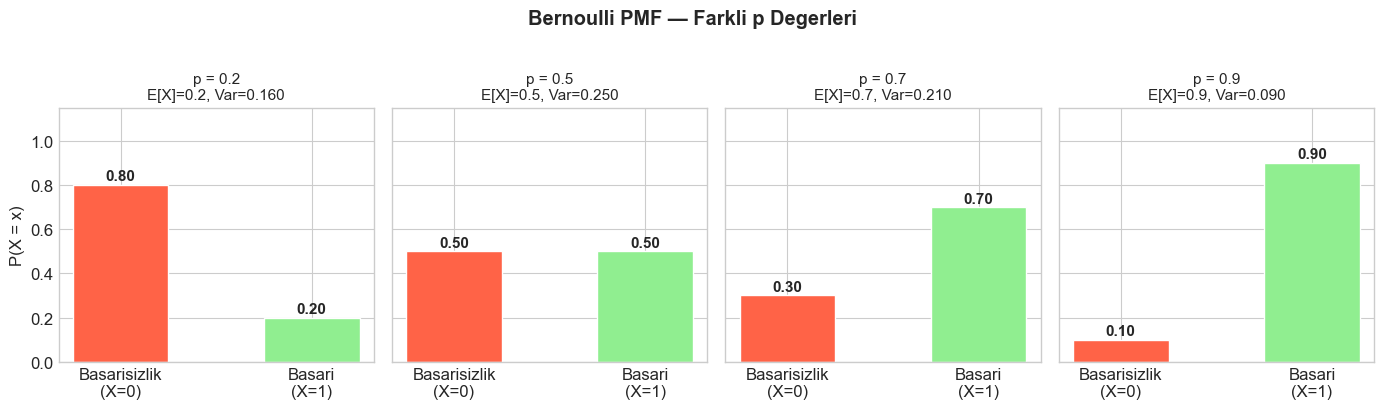

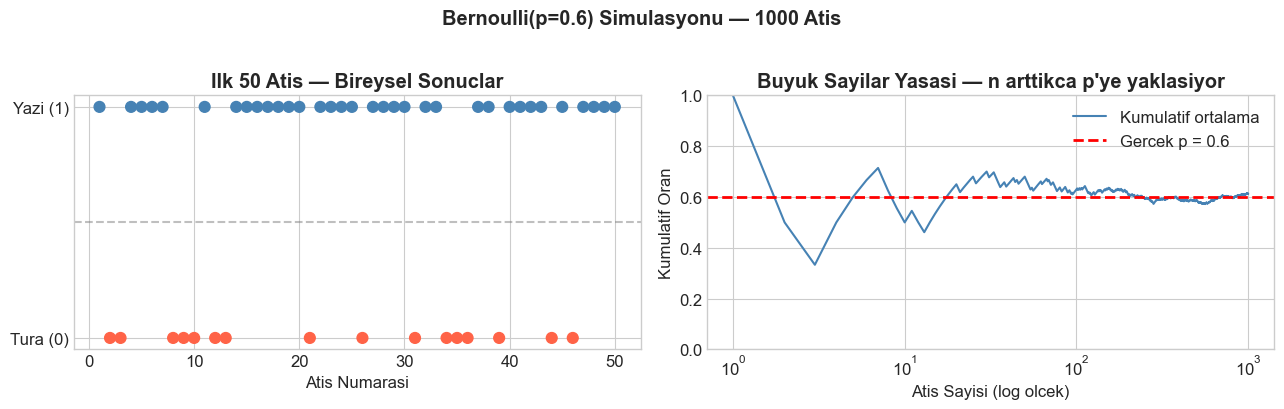

Simulasyonda yazi orani : 0.6130
Gercek p               : 0.6
Fark                   : 0.0130

E[X]   = p      = 0.6
Var(X) = p(1-p) = 0.2400


In [8]:
# ─── Bernoulli PMF: farkli p degerleri ───────────────────────────────────────
p_values = [0.2, 0.5, 0.7, 0.9]
outcomes = [0, 1]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for ax, p in zip(axes, p_values):
    dist = stats.bernoulli(p)
    probs = dist.pmf(outcomes)          # [P(X=0), P(X=1)] = [1-p, p]

    bars = ax.bar(
        ['Basarisizlik\n(X=0)', 'Basari\n(X=1)'],
        probs,
        color=['tomato', 'lightgreen'],
        width=0.5,
        edgecolor='white'
    )
    # Bar uzerine deger yaz
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.2f}', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylim(0, 1.15)
    ax.set_title(f'p = {p}\nE[X]={p:.1f}, Var={p*(1-p):.3f}', fontsize=11)
    ax.set_ylabel('P(X = x)' if ax == axes[0] else '')

plt.suptitle('Bernoulli PMF — Farkli p Degerleri', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Coin Flip Simulasyonu + LLN ─────────────────────────────────────────────
# Buyuk Sayilar Yasasi: n buyudukce kumulatif ortalama p'ye yaklasiyor
rng  = np.random.default_rng(42)       # tekrar uretilmesi icin seed
p_gercek = 0.6                         # oynargili para: yazinin gelmesi daha cok
n_deney  = 1000

# stats.bernoulli.rvs(): n bagimsiz Bernoulli denemesi uret
# Her eleman 1 (yazi) veya 0 (tura)
atislar      = stats.bernoulli.rvs(p=p_gercek, size=n_deney, random_state=42)
kumulatif_ort = np.cumsum(atislar) / np.arange(1, n_deney + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Sol: ilk 50 deneme — bireysel sonuclar
ax1.scatter(range(1, 51), atislar[:50],
            c=['steelblue' if x==1 else 'tomato' for x in atislar[:50]],
            s=60, zorder=3)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Tura (0)', 'Yazi (1)'])
ax1.set_xlabel('Atis Numarasi')
ax1.set_title('Ilk 50 Atis — Bireysel Sonuclar', fontweight='bold')

# Sag: kumulatif ortalama → LLN
ax2.plot(range(1, n_deney+1), kumulatif_ort, color='steelblue', linewidth=1.5,
         label='Kumulatif ortalama')
ax2.axhline(p_gercek, color='red', linestyle='--', linewidth=2,
            label=f'Gercek p = {p_gercek}')
ax2.set_xscale('log')    # log skala: baslangictaki gida dalgalanmasini goster
ax2.set_ylim(0, 1)
ax2.set_xlabel('Atis Sayisi (log olcek)')
ax2.set_ylabel('Kumulatif Oran')
ax2.set_title('Buyuk Sayilar Yasasi — n arttikca p\'ye yaklasiyor', fontweight='bold')
ax2.legend()

plt.suptitle(f'Bernoulli(p={p_gercek}) Simulasyonu — {n_deney} Atis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Manuel hesap kontrolu
print(f'Simulasyonda yazi orani : {atislar.mean():.4f}')
print(f'Gercek p               : {p_gercek}')
print(f'Fark                   : {abs(atislar.mean() - p_gercek):.4f}')
print(f'\nE[X]   = p      = {p_gercek}')
print(f'Var(X) = p(1-p) = {p_gercek*(1-p_gercek):.4f}')


---
### 📊 Python 2 — Binomial PMF: $n$ ve $p$ Değişince Ne Olur?

**Ne yapıyoruz?**  
Parametreleri değiştirerek Binomial PMF'inin şeklini inceliyoruz.

**Mantık:**
- `stats.binom(n, p)` → Binomial dağılım nesnesi
- `.pmf(k)` → $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$
- `np.arange(0, n+1)` → $k \in \{0, 1, \ldots, n\}$

**Gözlemlenecekler:**
- $p = 0.5$ → simetrik çan şekli
- $p < 0.5$ → sola çarpık (sol tarafa yığılmış)
- $p > 0.5$ → sağa çarpık
- $n$ büyüdükçe → Normal'e benziyor (CLT)

=== Binom Katsayisi C(n,k) Ornekleri ===
  C(  5, 2) =              10
  C( 10, 3) =             120
  C( 20, 7) =          77,520
  C(100,50) = 100,891,344,545,564,193,334,812,497,256

n=5, p=0.3, k=2 icin manuel PMF hesabi:
  C(5,2) x 0.3^2 x 0.7^3 = 10 x 0.0900 x 0.3430
  Manuel : 0.3087
  SciPy  : 0.3087


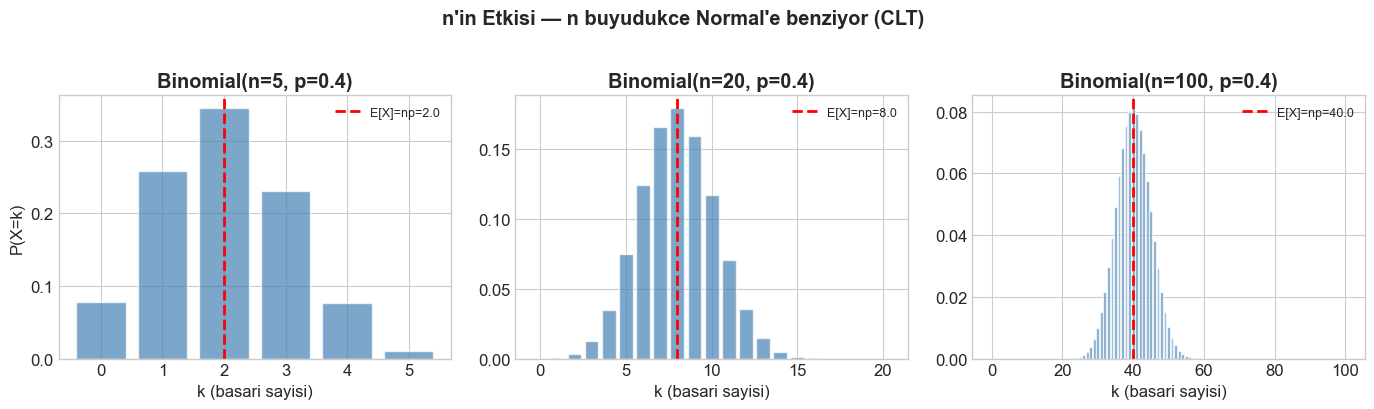

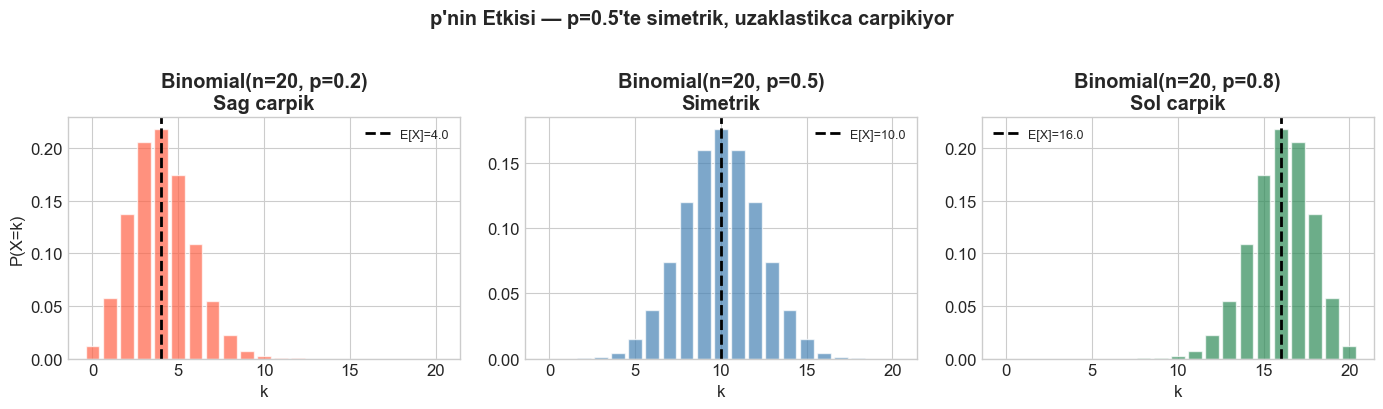

In [9]:
# ─── Binom katsayisi hesabi (anlama icin) ────────────────────────────────────
print('=== Binom Katsayisi C(n,k) Ornekleri ===')
for n, k in [(5,2), (10,3), (20,7), (100,50)]:
    # comb(n, k, exact=True) → tam tam faktoryel hesabi (float hatasi yok)
    print(f'  C({n:3d},{k:2d}) = {int(comb(n,k,exact=True)):>15,}')

print()
print('n=5, p=0.3, k=2 icin manuel PMF hesabi:')
n, k, p = 5, 2, 0.3
binom_katsayi = comb(n, k, exact=True)
pmf_manuel    = binom_katsayi * p**k * (1-p)**(n-k)
pmf_scipy     = stats.binom.pmf(k, n, p)
print(f'  C(5,2) x 0.3^2 x 0.7^3 = {binom_katsayi} x {p**k:.4f} x {(1-p)**(n-k):.4f}')
print(f'  Manuel : {pmf_manuel:.4f}')
print(f'  SciPy  : {pmf_scipy:.4f}')

# ─── n'in etkisi ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
p_sabit   = 0.4

for ax, n in zip(axes, [5, 20, 100]):
    k_vals = np.arange(0, n+1)
    pmf    = stats.binom.pmf(k_vals, n, p_sabit)

    ax.bar(k_vals, pmf, color='steelblue', alpha=0.7, width=0.8, edgecolor='white')
    # Beklenti ise areti
    mu = n * p_sabit
    ax.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'E[X]=np={mu:.1f}')
    ax.set_title(f'Binomial(n={n}, p={p_sabit})', fontweight='bold')
    ax.set_xlabel('k (basari sayisi)')
    ax.set_ylabel('P(X=k)' if ax == axes[0] else '')
    ax.legend(fontsize=9)

plt.suptitle("n'in Etkisi — n buyudukce Normal'e benziyor (CLT)", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── p'nin etkisi ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
n_sabit   = 20
renkler   = ['tomato', 'steelblue', 'seagreen']

for ax, (p_val, renk) in zip(axes, [(0.2,'tomato'), (0.5,'steelblue'), (0.8,'seagreen')]):
    k_vals = np.arange(0, n_sabit+1)
    pmf    = stats.binom.pmf(k_vals, n_sabit, p_val)

    ax.bar(k_vals, pmf, color=renk, alpha=0.7, width=0.8, edgecolor='white')
    mu = n_sabit * p_val
    ax.axvline(mu, color='black', linestyle='--', linewidth=2, label=f'E[X]={mu:.1f}')
    carpiklik = 'Sol carpik' if p_val > 0.5 else ('Sag carpik' if p_val < 0.5 else 'Simetrik')
    ax.set_title(f'Binomial(n={n_sabit}, p={p_val})\n{carpiklik}', fontweight='bold')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)' if ax == axes[0] else '')
    ax.legend(fontsize=9)

plt.suptitle("p'nin Etkisi — p=0.5'te simetrik, uzaklastikca carpikiyor", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
### 📉 Python 3 — Binomial CDF ile Olasılık Soruları

**Ne yapıyoruz?**  
Gerçek hayat sorularını CDF kullanarak cevaplıyoruz.

**Senaryo:** Bir e-posta kampanyası gönderiyoruz.  
- 50 e-posta gönderildi
- Her e-postanın açılma ihtimali %35
- $X \sim \text{Binomial}(50, 0.35)$

**Mantık:**
- `.cdf(k)` → $P(X \leq k)$ — "en fazla k adet açılma"
- `1 - .cdf(k-1)` → $P(X \geq k)$ — "en az k adet açılma"
- `.cdf(b) - .cdf(a-1)` → $P(a \leq X \leq b)$ — aralık

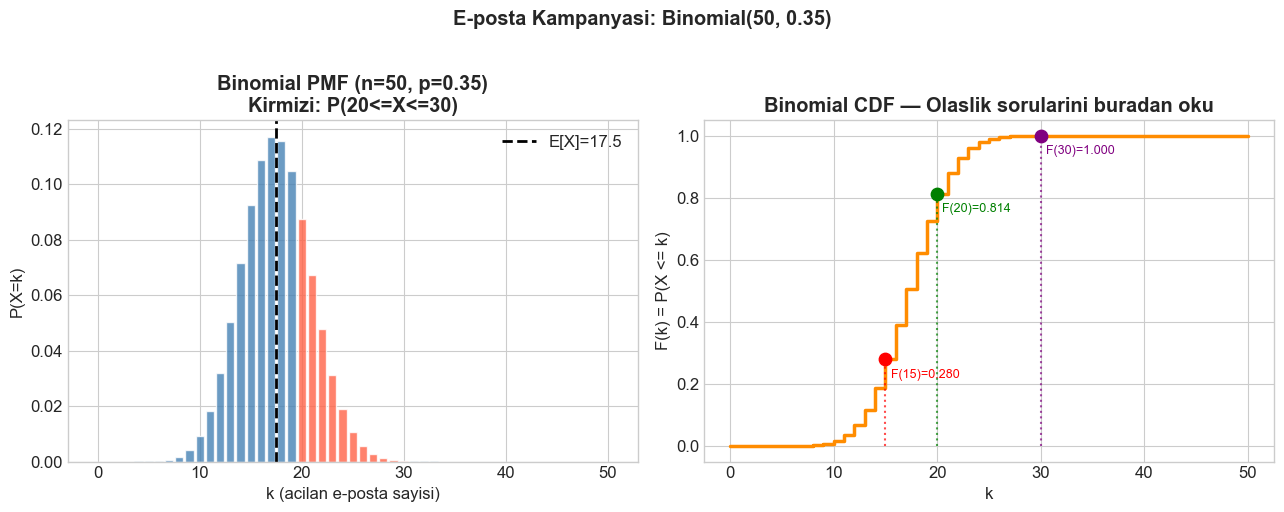

=== E-posta Kampanyasi Olaslik Sorulari ===
Dagilim: Binomial(n=50, p=0.35)
E[X] = np = 17.5   Var(X) = 11.38   Std = 3.37

P(X <= 15) = 0.2801  En fazla 15 e-posta acilir
P(X >= 20) = 0.2736  En az 20 e-posta acilir
P(15<=X<=25) = 0.8022  15 ile 25 arasinda acilir
P(X = 17)  = 0.1171  Tam olarak 17 e-posta acilir
%90 yuzdelik = 22 — acilma sayisi yuzde 90 ihtimalle bu degerin altindadir


In [10]:
n_kampanya = 50
p_acilma   = 0.35
dist       = stats.binom(n=n_kampanya, p=p_acilma)

k_vals = np.arange(0, n_kampanya + 1)
pmf    = dist.pmf(k_vals)
cdf    = dist.cdf(k_vals)

# ─── Grafik: PMF + CDF ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PMF: belirli araliklari vurgula
renkler_pmf = ['steelblue'] * (n_kampanya + 1)
for i in range(20, 31):          # P(20 <= X <= 30) araligini vurgula
    renkler_pmf[i] = 'tomato'

ax1.bar(k_vals, pmf, color=renkler_pmf, alpha=0.8, width=0.8, edgecolor='white')
mu_k = dist.mean()
ax1.axvline(mu_k, color='black', linestyle='--', linewidth=2, label=f'E[X]={mu_k:.1f}')
ax1.set_xlabel('k (acilan e-posta sayisi)')
ax1.set_ylabel('P(X=k)')
ax1.set_title(f'Binomial PMF (n={n_kampanya}, p={p_acilma})\nKirmizi: P(20<=X<=30)', fontweight='bold')
ax1.legend()

# CDF
ax2.step(k_vals, cdf, where='post', color='darkorange', linewidth=2.5)
# Sorularin isaretleri
for soru_k, renk in [(15,'red'), (20,'green'), (30,'purple')]:
    cdf_val = dist.cdf(soru_k)
    ax2.scatter([soru_k], [cdf_val], color=renk, zorder=5, s=80)
    ax2.plot([soru_k, soru_k], [0, cdf_val], color=renk, linestyle=':', alpha=0.7)
    ax2.text(soru_k + 0.5, cdf_val - 0.06, f'F({soru_k})={cdf_val:.3f}',
             color=renk, fontsize=9)

ax2.set_xlabel('k')
ax2.set_ylabel('F(k) = P(X <= k)')
ax2.set_title('Binomial CDF — Olaslik sorularini buradan oku', fontweight='bold')

plt.suptitle(f'E-posta Kampanyasi: Binomial({n_kampanya}, {p_acilma})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Olaslik sorulari ────────────────────────────────────────────────────────
print('=== E-posta Kampanyasi Olaslik Sorulari ===')
print(f'Dagilim: Binomial(n={n_kampanya}, p={p_acilma})')
print(f'E[X] = np = {dist.mean():.1f}   Var(X) = {dist.var():.2f}   Std = {dist.std():.2f}')
print()

# P(X <= 15): en fazla 15 acilma
p_en_fazla_15 = dist.cdf(15)
print(f'P(X <= 15) = {p_en_fazla_15:.4f}  En fazla 15 e-posta acilir')

# P(X >= 20): en az 20 acilma = 1 - P(X <= 19)
p_en_az_20 = 1 - dist.cdf(19)
print(f'P(X >= 20) = {p_en_az_20:.4f}  En az 20 e-posta acilir')

# P(15 <= X <= 25): aralik
p_aralik = dist.cdf(25) - dist.cdf(14)
print(f'P(15<=X<=25) = {p_aralik:.4f}  15 ile 25 arasinda acilir')

# P(X = 17): tam olarak 17
p_tam_17 = dist.pmf(17)
print(f'P(X = 17)  = {p_tam_17:.4f}  Tam olarak 17 e-posta acilir')

# %90 yuzdelik: en az hangi acilma sayisi garanti?
q90 = dist.ppf(0.90)
print(f'%90 yuzdelik = {int(q90)} — acilma sayisi yuzde 90 ihtimalle bu degerin altindadir')


---
### 🚢 Python 4 — Gerçek Veri: Titanic Hayatta Kalma

**Ne yapıyoruz?**  
Titanic yolcularının hayatta kalmasını Binomial ile modelliyoruz:
- Her yolcu: Bernoulli denemesi (1 = hayatta, 0 = hayatını kaybetti)
- Toplam hayatta kalan sayısı: Binomial($n$, $\hat{p}$)

**Mantık:**
- **MLE tahmini:** $\hat{p} = \frac{\text{hayatta kalan}}{\text{toplam yolcu}} = \frac{k}{n}$  
  Bu, Binomial için maksimum likelihood tahminidir — en basit ve sezgisel yöntem.
- Cinsiyet grubuna göre ayrı $\hat{p}$ tahmini: farklı alt gruplarda model farklı!

Toplam yolcu : 891
Hayatta kalan: 342
p_hat (MLE)  : 0.3838  = 342/891

Cinsiyete gore hayatta kalma:
        hayatta  toplam     p_hat
sex                              
female      233     314  0.742038
male        109     577  0.188908


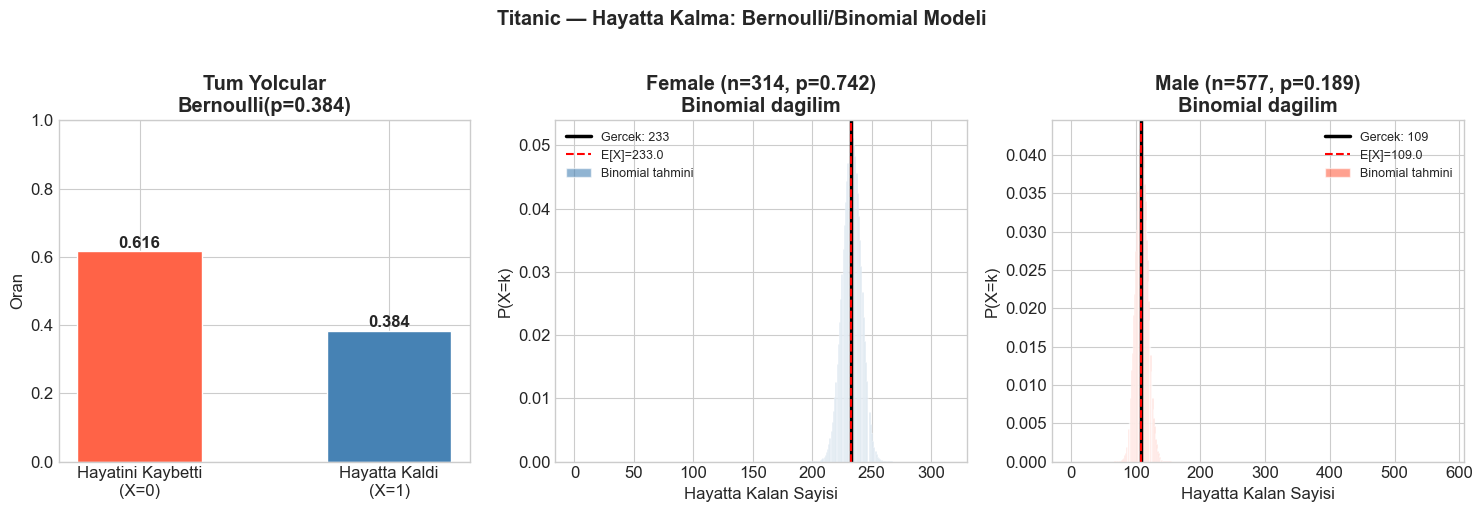


=== Kadin Yolcular (n=314, p=0.7420) ===
Gercekte hayatta kalan: 233
E[X] = 233.0  Std = 7.8
P(X = 233) = 0.0514  (gercekte gozlemlenen deger)
P(X >= 233) = 0.5298


In [11]:
titanic = sns.load_dataset('titanic')

# ─── Genel hayatta kalma orani (MLE ile p tahmini) ───────────────────────────
n_toplam   = len(titanic)
k_hayatta  = titanic['survived'].sum()
p_hat      = k_hayatta / n_toplam    # MLE tahmini: p_hat = k/n

print(f'Toplam yolcu : {n_toplam}')
print(f'Hayatta kalan: {k_hayatta}')
print(f'p_hat (MLE)  : {p_hat:.4f}  = {k_hayatta}/{n_toplam}')

# ─── Cinsiyet bazli p tahmini ─────────────────────────────────────────────────
grup = titanic.groupby('sex')['survived'].agg(['sum','count'])
grup['p_hat'] = grup['sum'] / grup['count']
print(f'\nCinsiyete gore hayatta kalma:')
print(grup.rename(columns={'sum':'hayatta','count':'toplam'}).to_string())

# ─── Grafik: Gercek veri vs Binomial tahmin ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sol: Tum yolcular — bar chart (Bernoulli PMF)
ax = axes[0]
counts = titanic['survived'].value_counts().sort_index()
renkler = ['tomato', 'steelblue']
bars = ax.bar(['Hayatini Kaybetti\n(X=0)', 'Hayatta Kaldi\n(X=1)'],
              counts.values / n_toplam, color=renkler, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values / n_toplam):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title(f'Tum Yolcular\nBernoulli(p={p_hat:.3f})', fontweight='bold')
ax.set_ylabel('Oran')

# Orta ve Sag: cinsiyet bazli Binomial dagilim karsilastirmasi
for ax, (cinsiyet, renk) in zip(axes[1:], [('female','steelblue'),('male','tomato')]):
    n_c = int(grup.loc[cinsiyet,'count'])
    p_c = grup.loc[cinsiyet,'p_hat']

    k_vals = np.arange(0, n_c+1)
    pmf    = stats.binom.pmf(k_vals, n_c, p_c)

    ax.bar(k_vals, pmf, color=renk, alpha=0.6, width=0.8, edgecolor='white',
           label='Binomial tahmini')
    gercek_k = int(grup.loc[cinsiyet,'sum'])
    ax.axvline(gercek_k, color='black', linewidth=2.5,
               label=f'Gercek: {gercek_k}')
    ax.axvline(n_c * p_c, color='red', linestyle='--', linewidth=1.5,
               label=f'E[X]={n_c*p_c:.1f}')
    ax.set_title(f'{cinsiyet.capitalize()} (n={n_c}, p={p_c:.3f})\nBinomial dagilim', fontweight='bold')
    ax.set_xlabel('Hayatta Kalan Sayisi')
    ax.set_ylabel('P(X=k)')
    ax.legend(fontsize=9)

plt.suptitle('Titanic — Hayatta Kalma: Bernoulli/Binomial Modeli', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Olaslik sorulari (kadin yolcular) ───────────────────────────────────────
n_kadin = int(grup.loc['female','count'])
p_kadin = grup.loc['female','p_hat']
dist_k  = stats.binom(n_kadin, p_kadin)

print(f'\n=== Kadin Yolcular (n={n_kadin}, p={p_kadin:.4f}) ===')
print(f'Gercekte hayatta kalan: {int(grup.loc["female","sum"])}')
print(f'E[X] = {dist_k.mean():.1f}  Std = {dist_k.std():.1f}')
gercek = int(grup.loc['female','sum'])
print(f'P(X = {gercek}) = {dist_k.pmf(gercek):.4f}  (gercekte gozlemlenen deger)')
print(f'P(X >= {gercek}) = {1 - dist_k.cdf(gercek-1):.4f}')


---
### 📈 Python 5 — Normal Yaklaşımı: $n$ Büyüyünce Binomial Nasıl Değişir?

**Ne yapıyoruz?**  
$n$ artarken Binomial PMF'i ile Normal PDF'i üst üste çiziyor, yaklaşımı görsel olarak doğruluyoruz.

**Mantık:**
- Binomial($n$, $p$) → $N(np, \; np(1-p))$ yaklaşımı
- Süreklilik düzeltmesi: $P(X=k) \approx P(k-0.5 \leq Z \leq k+0.5)$
- KL divergence: iki dağılım arasındaki farkı ölçer — küçüldükçe yaklaşım iyileşiyor

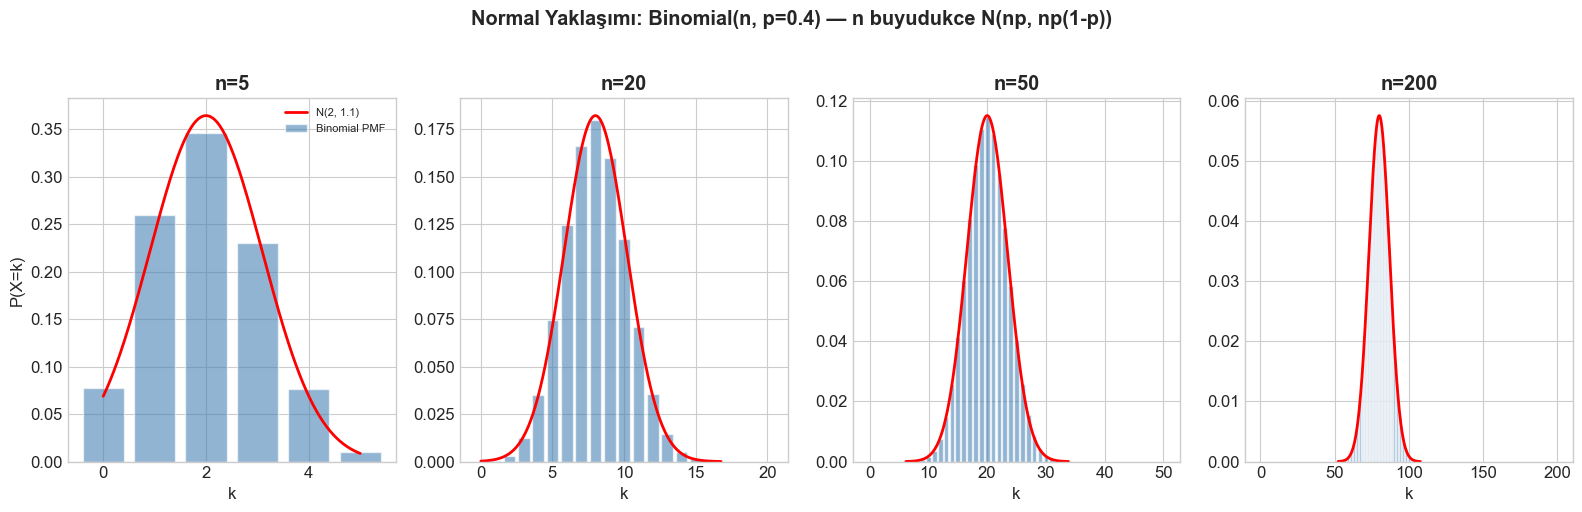

=== Normal Yaklasim Hatasi ===
     n       mu      std     P(X<=mu)_Binom    P(X<=mu)_Normal     Hata
     5      2.0     1.10             0.6826             0.5000   0.1826
    10      4.0     1.55             0.6331             0.5000   0.1331
    20      8.0     2.19             0.5956             0.5000   0.0956
    50     20.0     3.46             0.5610             0.5000   0.0610
   100     40.0     4.90             0.5433             0.5000   0.0433
   500    200.0    10.95             0.5194             0.5000   0.0194


In [12]:
p_val = 0.4
n_list = [5, 20, 50, 200]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, n in zip(axes, n_list):
    mu_b  = n * p_val
    std_b = np.sqrt(n * p_val * (1 - p_val))

    k_vals = np.arange(0, n+1)
    pmf    = stats.binom.pmf(k_vals, n, p_val)

    # Binomial PMF — bar
    ax.bar(k_vals, pmf, color='steelblue', alpha=0.6, width=0.8,
           edgecolor='white', label='Binomial PMF')

    # Normal PDF — sureçkli yaklasim
    x_cont = np.linspace(max(0, mu_b - 4*std_b), min(n, mu_b + 4*std_b), 300)
    ax.plot(x_cont, stats.norm.pdf(x_cont, mu_b, std_b),
            'red', linewidth=2, label=f'N({mu_b:.0f}, {std_b:.1f})')

    ax.set_title(f'n={n}', fontweight='bold')
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)' if n == 5 else '')
    if n == 5:
        ax.legend(fontsize=8)

plt.suptitle(f'Normal Yaklaşımı: Binomial(n, p={p_val}) — n buyudukce N(np, np(1-p))',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Numerik: yaklasim hatasinin azalmasi ─────────────────────────────────────
print('=== Normal Yaklasim Hatasi ===')
print(f'{"n":>6} {"mu":>8} {"std":>8} {"P(X<=mu)_Binom":>18} {"P(X<=mu)_Normal":>18} {"Hata":>8}')
for n in [5, 10, 20, 50, 100, 500]:
    mu  = n * p_val
    std = np.sqrt(n * p_val * (1-p_val))
    pb  = stats.binom.cdf(int(mu), n, p_val)
    pn  = stats.norm.cdf(mu, mu, std)
    print(f'{n:>6} {mu:>8.1f} {std:>8.2f} {pb:>18.4f} {pn:>18.4f} {abs(pb-pn):>8.4f}')


---
# 📊 R Uygulaması

Python'da gördüklerimizin aynısını R'da yapacağız.  
R'da Binomial için 4 hazır fonksiyon:

| Fonksiyon | Ne yapar? | Python karşılığı |
|---|---|---|
| `dbinom(k, n, p)` | $P(X=k)$ — PMF | `stats.binom.pmf(k, n, p)` |
| `pbinom(q, n, p)` | $P(X \leq q)$ — CDF | `stats.binom.cdf(q, n, p)` |
| `qbinom(prob, n, p)` | Quantile — CDF tersi | `stats.binom.ppf(prob, n, p)` |
| `rbinom(size, n, p)` | Rastgele örnekleme | `stats.binom.rvs(n, p, size=...)` |

In [13]:
%load_ext rpy2.ipython


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🎲 R 1 — Bernoulli PMF + Binomial PMF: p'nin Etkisi

**Yeni R kavramı:** `sapply()`  
Python'daki list comprehension veya `np.vectorize()` gibi —  
bir vektördeki her elemana fonksiyon uygular ve sonuçları vektöre toplar.

```r
sapply(0:n, function(k) dbinom(k, n, p))
# eşdeğer Python: np.array([stats.binom.pmf(k, n, p) for k in range(n+1)])
```


=== Binomial olaslik sorulari (n=50, p=0.35) ===
P(X <= 15) = 0.2801 
P(X >= 20) = 0.2736 
P(15<=X<=25) = 0.8022 
%90 yuzdelik = 22 


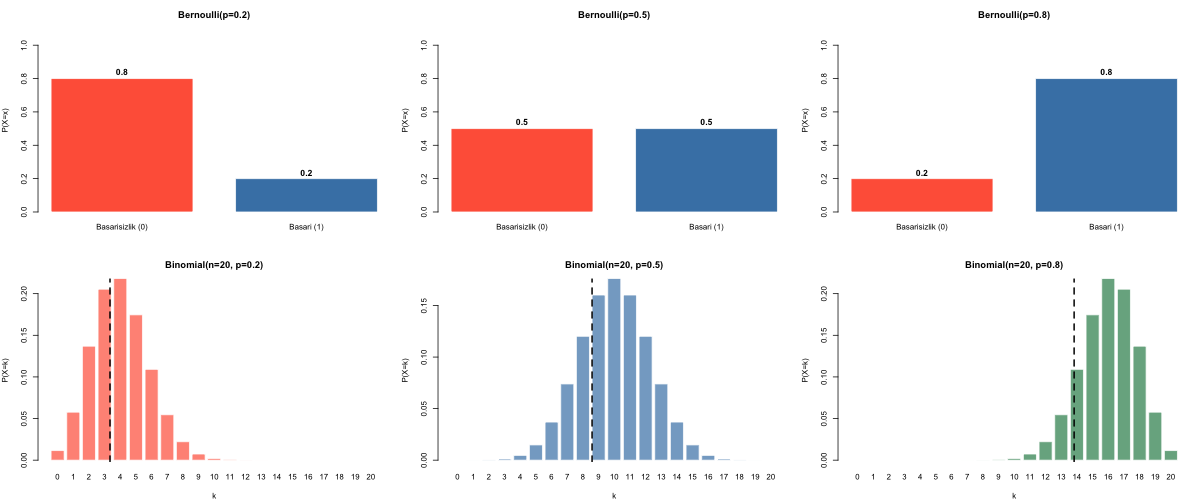

In [22]:
%%R -i titanic -w 1200 -h 500
# -i titanic: Python'daki titanic DataFrame'ini R'a aktar

# ─── Bernoulli PMF: p = 0.3 ve p = 0.7 ──────────────────────────────────────
par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

for (p in c(0.2, 0.5, 0.8)) {
  probs <- c(1-p, p)    # [P(X=0), P(X=1)]
  bp <- barplot(
    probs,
    names.arg = c('Basarisizlik (0)', 'Basari (1)'),
    col       = c('tomato', 'steelblue'),
    border    = 'white',
    ylim      = c(0, 1.1),
    main      = paste0('Bernoulli(p=', p, ')'),
    ylab      = 'P(X=x)',
    space     = 0.3
  )
  text(bp, probs + 0.04, labels = round(probs, 2), cex = 1.1, font = 2)
}

# ─── Binomial PMF: n=20, farkli p degerleri ─────────────────────────────────
n <- 20
renkler <- c('tomato', 'steelblue', 'seagreen')

for (i in seq_along(c(0.2, 0.5, 0.8))) {
  p <- c(0.2, 0.5, 0.8)[i]
  k <- 0:n
  # dbinom: Binomial PMF (Python'daki stats.binom.pmf ile ayni)
  pmf_vals <- dbinom(k, size = n, prob = p)

  barplot(
    pmf_vals,
    names.arg = k,
    col       = adjustcolor(renkler[i], alpha.f = 0.7),
    border    = 'white',
    main      = paste0('Binomial(n=', n, ', p=', p, ')'),
    xlab      = 'k',
    ylab      = 'P(X=k)'
  )
  # Beklenti isaretini ekle
  # n*p beklentisinin indeksi: x ekseninde hangi cubuk?
  abline(v = (n*p + 0.5) * (n+2)/(n+1),  # barplot x-cinsinden yer
         col = 'black', lty = 2, lwd = 2)
}

par(mfrow = c(1, 1))

# ─── Sayisal kontrol ─────────────────────────────────────────────────────────
cat('\n=== Binomial olaslik sorulari (n=50, p=0.35) ===\n')
n <- 50; p <- 0.35
cat('P(X <= 15) =', round(pbinom(15, n, p), 4), '\n')
cat('P(X >= 20) =', round(1 - pbinom(19, n, p), 4), '\n')
cat('P(15<=X<=25) =', round(pbinom(25,n,p) - pbinom(14,n,p), 4), '\n')
cat('%90 yuzdelik =', qbinom(0.90, n, p), '\n')


---
### 🚢 R 2 — Titanic: Binomial Fit + CDF

**Yeni R kavramları:**
- `table()` → frekans tablosu (Python'daki `value_counts()` gibi)
- `tapply(x, grp, fn)` → gruba göre fonksiyon uygula (`groupby().apply()` benzeri)
- `which.min()` → minimum değerin indeksini bul

Toplam yolcu :  891 
Hayatta kalan: 342 
p_hat (MLE)  :  0.3838 

Cinsiyete gore p_hat:
female   male 
0.7420 0.1889 


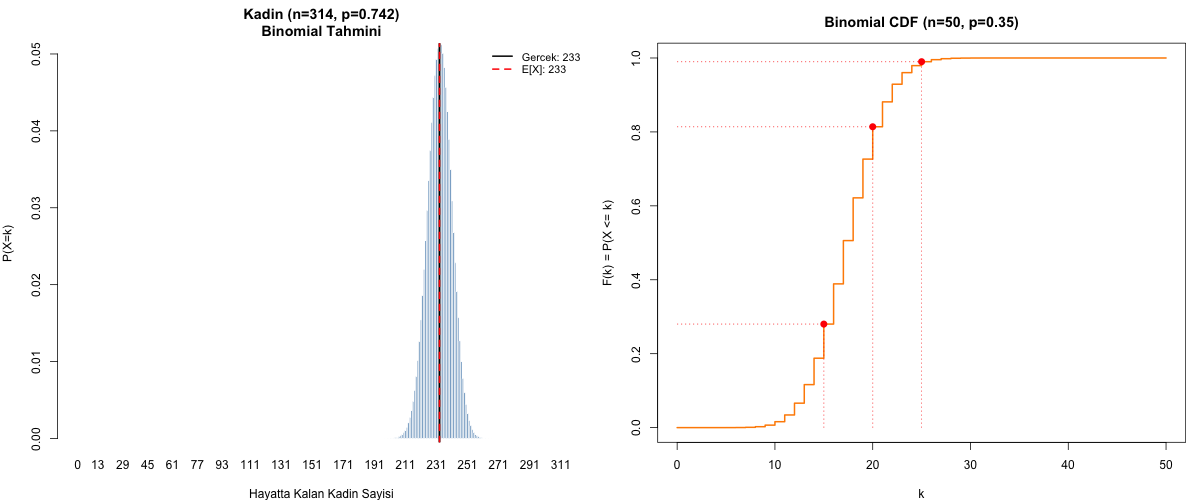

In [23]:
%%R -w 1200 -h 500
# titanic Python'dan zaten aktarildi (r-pmf-code hucresinde -i titanic)

# ─── p_hat tahmini (MLE) ─────────────────────────────────────────────────────
n_toplam  <- nrow(titanic)
k_hayatta <- sum(titanic$survived)
p_hat     <- k_hayatta / n_toplam    # MLE: p_hat = k/n

cat('Toplam yolcu : ', n_toplam, '\n')
cat('Hayatta kalan:', k_hayatta, '\n')
cat('p_hat (MLE)  : ', round(p_hat, 4), '\n')

# ─── Cinsiyet bazli p_hat ────────────────────────────────────────────────────
# tapply: gruba gore fonksiyon uygula (Python groupby+agg gibi)
p_cinsiyet <- tapply(titanic$survived, titanic$sex, mean)
n_cinsiyet <- tapply(titanic$survived, titanic$sex, length)
cat('\nCinsiyete gore p_hat:\n')
print(round(p_cinsiyet, 4))

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# ─── Sol: Kadin yolcular — Binomial PMF + gercek deger ───────────────────────
n_k <- n_cinsiyet['female']
p_k <- p_cinsiyet['female']
k_vals_k <- 0:n_k

pmf_k <- dbinom(k_vals_k, size = n_k, prob = p_k)

barplot(pmf_k, names.arg = k_vals_k,
        col    = 'steelblue',
        border = 'white',
        main   = paste0('Kadin (n=', n_k, ', p=', round(p_k,3), ')\nBinomial Tahmini'),
        xlab   = 'Hayatta Kalan Kadin Sayisi',
        ylab   = 'P(X=k)')

# Gercek gozlem: dikey cizgi
gercek_k <- sum(titanic$survived[titanic$sex == 'female'])
# barplot'ta x koordinati 1.2 katinda basliyor: indeks * 1.2
abline(v = (gercek_k + 0.5) * 1.2, col = 'black', lwd = 2.5)
abline(v = (n_k * p_k + 0.5) * 1.2, col = 'red', lty = 2, lwd = 2)
legend('topright',
       legend = c(paste('Gercek:', gercek_k), paste('E[X]:', round(n_k*p_k,1))),
       col = c('black','red'), lty = c(1,2), lwd = 2, bty='n', cex=0.9)

# ─── Sag: Binomial CDF — kumulatif olasilik ──────────────────────────────────
n_g <- 50; p_g <- 0.35
k_g <- 0:n_g
cdf_vals <- pbinom(k_g, size = n_g, prob = p_g)   # pbinom: Python dist.cdf() karsiligi

plot(k_g, cdf_vals,
     type = 's',
     col  = 'darkorange',
     lwd  = 2,
     main = 'Binomial CDF (n=50, p=0.35)',
     xlab = 'k',
     ylab = 'F(k) = P(X <= k)')

# Isaretler
for (k_i in c(15, 20, 25)) {
  cdf_i <- pbinom(k_i, n_g, p_g)
  points(k_i, cdf_i, pch=16, col='red', cex=1.3)
  segments(k_i, 0, k_i, cdf_i, col='red', lty=3)
  segments(0, cdf_i, k_i, cdf_i, col='red', lty=3)
}

par(mfrow = c(1, 1))


---
# 🗄️ SQL Uygulaması (DuckDB)

Aynı konuları SQL'de işleyeceğiz:
1. **Bernoulli** → Titanic'te her yolcunun başarı/başarısızlık oranı
2. **p_hat (MLE)** → Gruba göre hayatta kalma oranı
3. **Binomial PMF** → SQL ile manuel hesap (faktöriyel kullanarak)
4. **Olasılık soruları** → Kümülatif toplamla CDF tahmini

**Yeni SQL kavramı:** `FACTORIAL()` ve `POWER()` ile manuel PMF hesabı.  
DuckDB'de matematiksel fonksiyonlar doğrudan SELECT içinde kullanılabilir.

In [24]:
import duckdb

con = duckdb.connect()
con.register('titanic', titanic)
print('DuckDB hazir ✓')
print(f'titanic: {len(titanic)} satir, {len(titanic.columns)} sutun')


DuckDB hazir ✓
titanic: 891 satir, 15 sutun


---
### 🎲 SQL 1 — Bernoulli: Gruba Göre p_hat (MLE Tahmini)

SQL'de MLE tahmini aslında çok basit:  
$\hat{p} = \frac{\text{hayatta kalan}}{\text{toplam}}$ → `AVG(survived)` ile doğrudan hesaplanır.

```sql
AVG(survived)  -- survived 0 veya 1 olduğu için ortalaması direkt p_hat
```

Bu, Bernoulli dağılımı için maksimum likelihood tahminidir.

In [25]:
# ─── Genel ve gruba gore p_hat ────────────────────────────────────────────────
# survived 0/1 oldugu icin AVG() direkt p_hat veriyor — bu MLE'dir
genel = con.execute("""
    SELECT
        COUNT(*)                        AS n_toplam,
        SUM(survived)                   AS k_hayatta,
        ROUND(AVG(survived), 4)         AS p_hat,
        ROUND(AVG(survived) *
              (1 - AVG(survived)), 4)   AS varyans_hat,   -- Var = p*(1-p)
        ROUND(SQRT(AVG(survived) *
              (1 - AVG(survived))), 4)  AS std_hat
    FROM titanic
""").df()
print('=== Genel Hayatta Kalma (Bernoulli MLE) ===')
print(genel.to_string(index=False))

# ─── Cinsiyet bazli ─────────────────────────────────────────────────────────
cinsiyet = con.execute("""
    SELECT
        sex                             AS cinsiyet,
        COUNT(*)                        AS n,
        SUM(survived)                   AS k,
        ROUND(AVG(survived), 4)         AS p_hat,
        ROUND(COUNT(*) * AVG(survived) * (1-AVG(survived)), 4) AS binomial_varyans
    FROM titanic
    GROUP BY sex
    ORDER BY sex
""").df()
print('\n=== Cinsiyet Bazli Bernoulli ===')
print(cinsiyet.to_string(index=False))

# ─── Klas + Cinsiyet bazli (alt grup analizi) ────────────────────────────────
detay = con.execute("""
    SELECT
        pclass                          AS sinif,
        sex                             AS cinsiyet,
        COUNT(*)                        AS n,
        SUM(survived)                   AS k_hayatta,
        ROUND(AVG(survived), 3)         AS p_hat,
        -- Binomial E[X] ve Std
        ROUND(COUNT(*) * AVG(survived), 1)               AS beklenti,
        ROUND(SQRT(COUNT(*) * AVG(survived) *
              (1-AVG(survived))), 2)    AS std_binomial
    FROM titanic
    GROUP BY pclass, sex
    ORDER BY pclass, sex
""").df()
print('\n=== Sinif + Cinsiyet Bazli Analiz ===')
print(detay.to_string(index=False))


=== Genel Hayatta Kalma (Bernoulli MLE) ===
 n_toplam  k_hayatta  p_hat  varyans_hat  std_hat
      891      342.0 0.3838       0.2365   0.4863

=== Cinsiyet Bazli Bernoulli ===
cinsiyet   n     k  p_hat  binomial_varyans
  female 314 233.0 0.7420           60.1051
    male 577 109.0 0.1889           88.4090

=== Sinif + Cinsiyet Bazli Analiz ===
 sinif cinsiyet   n  k_hayatta  p_hat  beklenti  std_binomial
     1   female  94       91.0  0.968      91.0          1.70
     1     male 122       45.0  0.369      45.0          5.33
     2   female  76       70.0  0.921      70.0          2.35
     2     male 108       17.0  0.157      17.0          3.78
     3   female 144       72.0  0.500      72.0          6.00
     3     male 347       47.0  0.135      47.0          6.37


---
### 📊 SQL 2 — Binomial PMF: Manuel Hesap (FACTORIAL ile)

**Ne yapıyoruz?**  
$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$ formülünü SQL'de `FACTORIAL()` ve `POWER()` ile hesaplıyoruz.

```sql
FACTORIAL(n) / (FACTORIAL(k) * FACTORIAL(n-k))   -- C(n,k)
    * POWER(p, k)                                  -- p^k
    * POWER(1-p, n-k)                             -- (1-p)^(n-k)
```

Bu, Python'daki `stats.binom.pmf(k, n, p)` ile aynı hesaptır.

In [32]:
# Senaryo: 50 e-posta, p=0.35 acilma olasiligi
# P(X=k) degerlerini SQL'de hesapla
pmf_sql = con.execute("""
    WITH params AS (
        SELECT 50 AS n, 0.35 AS p
    ),
    k_values AS (
        -- k = 0, 1, 2, ..., n degerlerini uret
        SELECT unnest(generate_series(0, 50)) AS k
    )
    SELECT
        k,
        -- Binom katsayisi: n! / (k! * (n-k)!)
        ROUND(
            GAMMA(n + 1)::DOUBLE
            / (GAMMA(k + 1)::DOUBLE * GAMMA(n - k + 1)::DOUBLE)
            * POWER(p, k)
            * POWER(1.0 - p, n - k)
        , 6) AS pmf_deger,
        -- Kumulatif toplam = CDF tahmini
        ROUND(
            SUM(
                GAMMA(n + 1)::DOUBLE
                / (GAMMA(k + 1)::DOUBLE * GAMMA(n - k + 1)::DOUBLE)
                * POWER(p, k)
                * POWER(1.0 - p, n - k)
            ) OVER (ORDER BY k),
        6) AS cdf_deger
    FROM k_values, params
    WHERE k BETWEEN 5 AND 35    -- ilgi cekici aralik
    ORDER BY k
""").df()

print('=== Binomial PMF ve CDF (n=50, p=0.35) ===')
print(pmf_sql.to_string(index=False))
print(f'\nPMF toplamlari kontrol: {pmf_sql["pmf_deger"].sum():.4f} (1e yakin olmali)')


=== Binomial PMF ve CDF (n=50, p=0.35) ===
 k  pmf_deger  cdf_deger
 5   0.000042   0.000042
 6   0.000171   0.000214
 7   0.000580   0.000793
 8   0.001678   0.002471
 9   0.004216   0.006688
10   0.009309   0.015996
11   0.018227   0.034223
12   0.031896   0.066119
13   0.050204   0.116323
14   0.071444   0.187767
15   0.092327   0.280094
16   0.108751   0.388845
17   0.117117   0.505962
18   0.115615   0.621577
19   0.104849   0.726426
20   0.087509   0.813935
21   0.067314   0.881250
22   0.047779   0.929029
23   0.031320   0.960349
24   0.018973   0.979322
25   0.010625   0.989946
26   0.005501   0.995447
27   0.002633   0.998080
28   0.001165   0.999245
29   0.000476   0.999720
30   0.000179   0.999900
31   0.000062   0.999962
32   0.000020   0.999982
33   0.000006   0.999988
34   0.000002   0.999989
35   0.000000   0.999990

PMF toplamlari kontrol: 1.0000 (1e yakin olmali)


---
### 📐 SQL 3 — Olasılık Soruları: CDF Kümülatif Toplam

SQL'de CDF'yi **window function** ile hesapladığımızda,  
istediğimiz aralıktaki olasılığı `MAX(CASE WHEN ...)` ile okuyabiliriz.

Bu, önceki notebook'taki ECDF mantığının aynısı — sadece teorik PMF üzerinde.

In [33]:
sorular = con.execute("""
    WITH pmf_table AS (
        WITH params AS (SELECT 50 AS n, 0.35 AS p),
             k_vals AS (SELECT unnest(generate_series(0, 50)) AS k)
        SELECT
            k,
            GAMMA(n + 1)::DOUBLE
                / (GAMMA(k + 1)::DOUBLE * GAMMA(n - k + 1)::DOUBLE)
                * POWER(p, k) * POWER(1.0-p, n-k) AS pmf,
            SUM(GAMMA(n + 1)::DOUBLE
                / (GAMMA(k + 1)::DOUBLE * GAMMA(n - k + 1)::DOUBLE)
                * POWER(p,k) * POWER(1.0-p, n-k))
                OVER (ORDER BY k)                  AS cdf
        FROM k_vals, params
    )
    SELECT
        -- P(X <= 15): CDF'ten dogrudan
        ROUND(MAX(CASE WHEN k = 15 THEN cdf END), 4)           AS P_en_fazla_15,
        -- P(X >= 20): 1 - P(X <= 19)
        ROUND(1 - MAX(CASE WHEN k = 19 THEN cdf END), 4)       AS P_en_az_20,
        -- P(15 <= X <= 25): F(25) - F(14)
        ROUND(MAX(CASE WHEN k = 25 THEN cdf END)
            - MAX(CASE WHEN k = 14 THEN cdf END), 4)           AS P_15_ile_25,
        -- P(X = 17): tek bir PMF degeri
        ROUND(MAX(CASE WHEN k = 17 THEN pmf END), 4)           AS P_tam_17
    FROM pmf_table
""").df()

print('=== E-posta Kampanyasi Olaslik Sorulari (SQL) ===')
print(sorular.to_string(index=False))

print('\n=== Python ile karsilastir (ayni olmali) ===')
dist = stats.binom(50, 0.35)
print(f'P(X<=15)     Python={dist.cdf(15):.4f}   SQL={sorular["P_en_fazla_15"].values[0]}')
print(f'P(X>=20)     Python={1-dist.cdf(19):.4f}   SQL={sorular["P_en_az_20"].values[0]}')
print(f'P(15<=X<=25) Python={dist.cdf(25)-dist.cdf(14):.4f}   SQL={sorular["P_15_ile_25"].values[0]}')
print(f'P(X=17)      Python={dist.pmf(17):.4f}   SQL={sorular["P_tam_17"].values[0]}')


=== E-posta Kampanyasi Olaslik Sorulari (SQL) ===
 P_en_fazla_15  P_en_az_20  P_15_ile_25  P_tam_17
        0.2801      0.2736       0.8022    0.1171

=== Python ile karsilastir (ayni olmali) ===
P(X<=15)     Python=0.2801   SQL=0.2801
P(X>=20)     Python=0.2736   SQL=0.2736
P(15<=X<=25) Python=0.8022   SQL=0.8022
P(X=17)      Python=0.1171   SQL=0.1171


---
## ✏️ Egzersizler

**E1.** Bir fabrikada %5 oranında hatalı ürün çıkıyor. 100 ürün üretildiğinde:
- $X \sim$ Binomial(?, ?) — parametreleri belirle
- En fazla 3 hatalı ürün çıkma olasılığını hesapla
- En az 8 hatalı çıkma olasılığını hesapla
- $E[X]$ ve $\text{Var}(X)$'i hem formülle hem kodla hesapla

**E2.** Titanic verisinde `pclass` (bilet sınıfı) bazında:
- Her sınıf için ayrı Bernoulli modeli kur ($\hat{p}$ tahmin et)
- 3 sınıfın hayatta kalma oranlarını bar chart ile karşılaştır (Python + R + SQL)

**E3.** Bir A/B testinde:
- Kontrol grubu: 200 kullanıcı, 30 tıklama → $\hat{p}_{kontrol}$
- Test grubu: 200 kullanıcı, 42 tıklama → $\hat{p}_{test}$
- Her iki grubun Binomial dağılımını çiz
- $P(X_{test} > X_{kontrol})$'ü simülasyon ile tahmin et

**E4 (R).** `rbinom(n=1000, size=50, prob=0.35)` ile 1000 kampanya simüle et.  
Histogramı çiz ve teorik Binomial PMF ile karşılaştır.

**E5 (SQL).** Titanic'te `embarked` (binme limanı) ve `pclass` kombinasyonuna göre  
hayatta kalma oranını hesapla. En yüksek ve en düşük hayatta kalma hangi kombinasyonda?


=== Egzersiz 1: Bozuk Urun Ornegi ===
X ~ Binomial(n=100, p=0.05)
En fazla 3 ürünün bozuk olması P(X < 3) = 0.1183
En az 8 ürünün bozuk olması P(X >= 8) = 0.1280
E[X] = 5.0, Var(X) = 4.75, Std(X) = 2.18

=== Egzersiz 2: Titanic Yolculari ===

 Her sınıf için hayatta kalma olasılıklarını hesaplayın ve Binomial PMF grafiğini çizin.

Genel: n=891, p_hat=0.3838
Sınıf 1: n=216, p_hat=0.6296
Sınıf 2: n=184, p_hat=0.4728
Sınıf 3: n=491, p_hat=0.2424


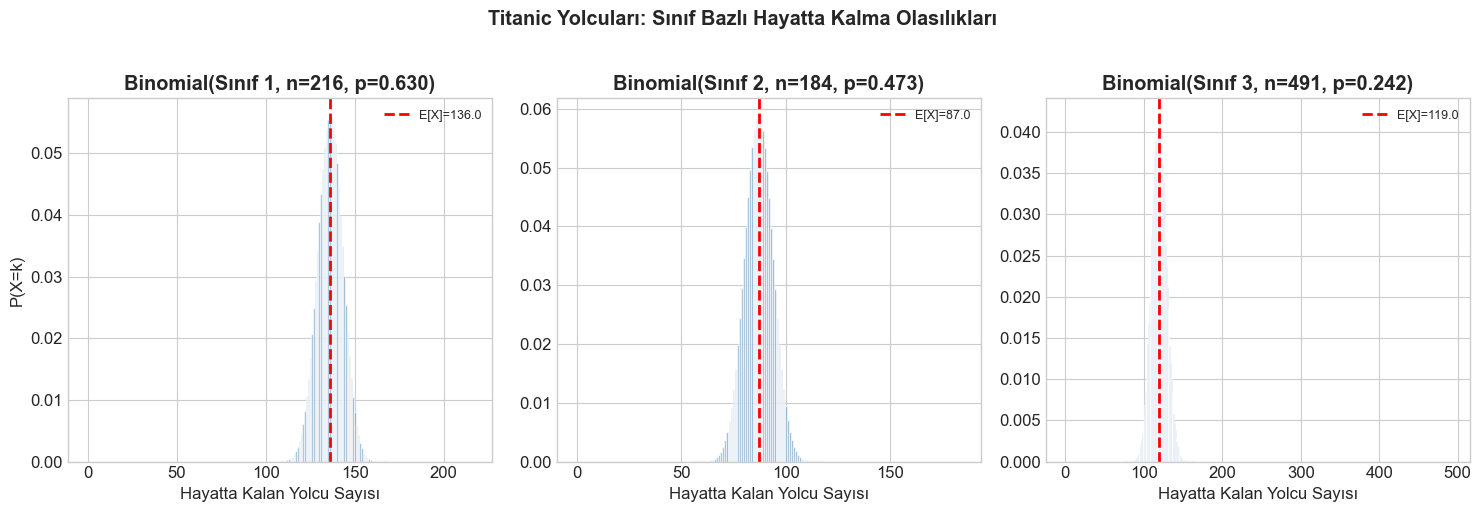


Egzersiz 3: A/B Testi — E-posta Kampanyası
Kontrol Grubu: n=200, p_hat=0.150
Test Grubu: n=200, p_hat=0.210


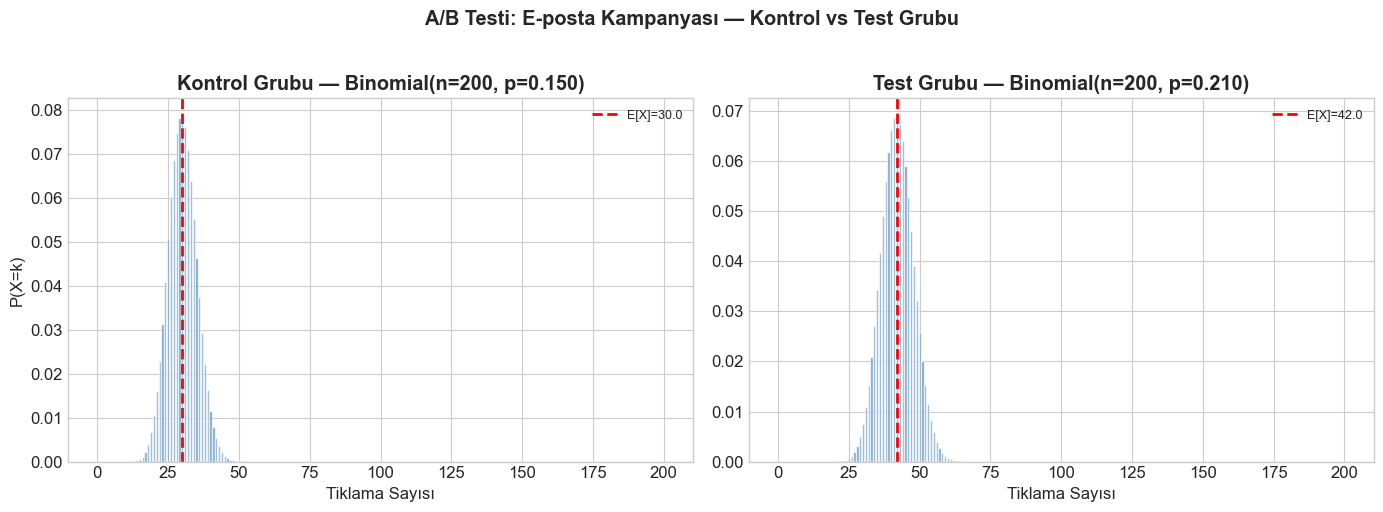

P(Xtest > Xkontrol) = 0.9335892656509017


In [57]:
# ===== Egzersiz 1 =====
print('\n=== Egzersiz 1: Bozuk Urun Ornegi ===')
# X ~ Binomial(n=100, p=0.05)
n_urun = 100
p_urun = 0.05
dist = stats.binom(n_urun, p_urun)

k_vals = np.arange(0, n_urun + 1)
pmf = dist.pmf(k_vals)
cdf = dist.cdf(k_vals)

print(f'X ~ Binomial(n={n_urun}, p={p_urun})')
print(f'En fazla 3 ürünün bozuk olması P(X < 3) = {dist.cdf(2):.4f}')
print(f'En az 8 ürünün bozuk olması P(X >= 8) = {1 - dist.cdf(7):.4f}')
print(f'E[X] = {dist.mean():.1f}, Var(X) = {dist.var():.2f}, Std(X) = {dist.std():.2f}')

# ===== Egzersiz 2 =====
print('\n=== Egzersiz 2: Titanic Yolculari ===')
print('\n Her sınıf için hayatta kalma olasılıklarını hesaplayın ve Binomial PMF grafiğini çizin.')
n_toplam = len(titanic)
k_hayatta = titanic['survived'].sum()
p_hat = k_hayatta / n_toplam

n_psinif1 = int(titanic[titanic['pclass'] == 1].shape[0])
p_hat_sinif1 = titanic[titanic['pclass'] == 1]['survived'].mean()
n_psinif2 = int(titanic[titanic['pclass'] == 2].shape[0])
p_hat_sinif2 = titanic[titanic['pclass'] == 2]['survived'].mean()
n_psinif3 = int(titanic[titanic['pclass'] == 3].shape[0])
p_hat_sinif3 = titanic[titanic['pclass'] == 3]['survived'].mean()

print(f'\nGenel: n={n_toplam}, p_hat={p_hat:.4f}')
print(f'Sınıf 1: n={n_psinif1}, p_hat={p_hat_sinif1:.4f}')
print(f'Sınıf 2: n={n_psinif2}, p_hat={p_hat_sinif2:.4f}')
print(f'Sınıf 3: n={n_psinif3}, p_hat={p_hat_sinif3:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (n, p_hat, sinif) in zip(axes, [(n_psinif1, p_hat_sinif1, 'Sınıf 1'), (n_psinif2, p_hat_sinif2, 'Sınıf 2'), (n_psinif3, p_hat_sinif3, 'Sınıf 3')]):
    k_vals = np.arange(0, n + 1)
    pmf = stats.binom.pmf(k_vals, n, p_hat)
    ax.bar(k_vals, pmf, color='steelblue', alpha=0.7, width=0.8, edgecolor='white')
    mu = n * p_hat
    ax.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'E[X]={mu:.1f}')
    ax.set_title(f'Binomial({sinif}, n={n}, p={p_hat:.3f})', fontweight='bold')
    ax.set_xlabel('Hayatta Kalan Yolcu Sayısı')
    ax.set_ylabel('P(X=k)' if sinif == 'Sınıf 1' else '')
    ax.legend(fontsize=9)
plt.suptitle('Titanic Yolcuları: Sınıf Bazlı Hayatta Kalma Olasılıkları', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nEgzersiz 3: A/B Testi — E-posta Kampanyası')
n_kontrolKullanici = 200
p_kontrolTiklama = 30
k_vals_kontrol = np.arange(0, n_kontrolKullanici + 1)

p_hat_kontrol = p_kontrolTiklama / n_kontrolKullanici
dist_ab_kontrol = stats.binom(n_kontrolKullanici, p_hat_kontrol)

n_testKullanici = 200
p_testTiklama = 42
k_vals_test = np.arange(0, n_testKullanici + 1)
p_hat_test = p_testTiklama / n_testKullanici
dist_ab_test = stats.binom(n_testKullanici, p_hat_test)
print(f'Kontrol Grubu: n={n_kontrolKullanici}, p_hat={p_hat_kontrol:.3f}')
print(f'Test Grubu: n={n_testKullanici}, p_hat={p_hat_test:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (dist, p_hat, grup) in zip(axes, [(dist_ab_kontrol, p_hat_kontrol, 'Kontrol Grubu'), (dist_ab_test, p_hat_test, 'Test Grubu')]):
    k_vals = np.arange(0, 200 + 1)
    pmf = dist.pmf(k_vals)
    ax.bar(k_vals, pmf, color='steelblue', alpha=0.7, width=0.8, edgecolor='white')
    mu = dist.mean()
    ax.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'E[X]={mu:.1f}')
    ax.set_title(f'{grup} — Binomial(n={200}, p={p_hat:.3f})', fontweight='bold')
    ax.set_xlabel('Tiklama Sayısı')
    ax.set_ylabel('P(X=k)' if grup == 'Kontrol Grubu' else '')
    ax.legend(fontsize=9)
plt.suptitle('A/B Testi: E-posta Kampanyası — Kontrol vs Test Grubu', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'P(Xtest > Xkontrol) = {sum(dist_ab_test.pmf(x) * dist_ab_kontrol.pmf(y) for x in range(0, 201) for y in range(0, 201) if x > y)}')



=== Egzersiz 4: Kampanya Simülasyonu ===
Simülasyon p = 0.35 
Simülasyon ortalaması = 17.719 


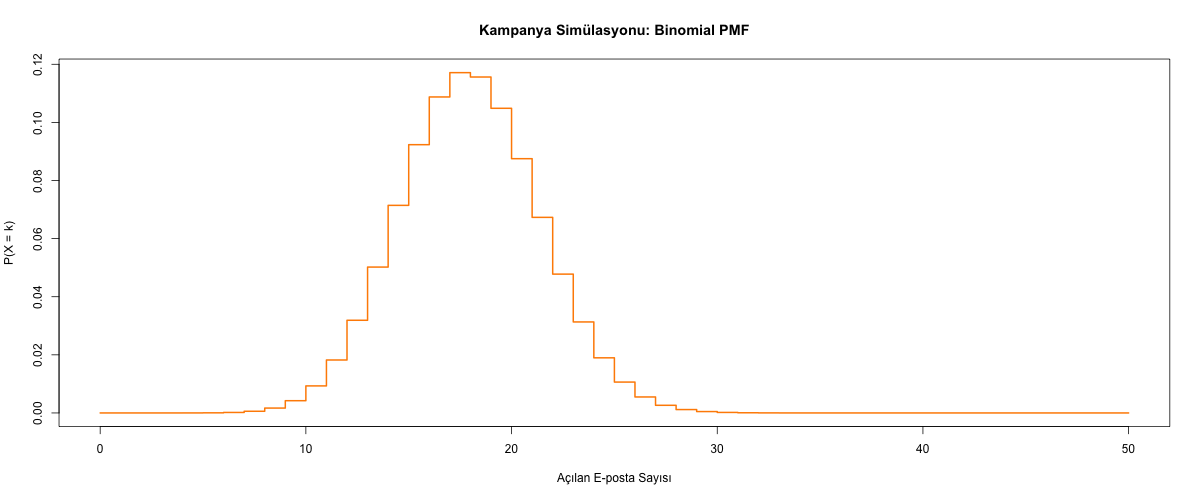

In [69]:
%%R -w 1200 -h 500
cat('\n=== Egzersiz 4: Kampanya Simülasyonu ===\n')


kabuller <- rbinom(1000, size=50, prob=0.35)
kumulatif <- cumsum(table(factor(kabuller, levels=0:50))) / n_deney
pmf_vals <- dbinom(0:50, size=50, prob=0.35)

plot(0:50, pmf_vals, type='s', col='darkorange', lwd=2,
     main='Kampanya Simülasyonu: Binomial PMF',
     xlab='Açılan E-posta Sayısı', ylab='P(X = k)')

cat('Simülasyon p =', 0.35, '\n')
cat('Simülasyon ortalaması =', mean(kabuller), '\n')

In [73]:
print("\n Egzersiz 5: embarked ve pclass Kombinasyonuna Göre Hayatta Kalma Olasılıkları")

detay = con.execute("""
    SELECT
        embarked AS liman, 
        pclass AS sinif,
        COUNT(*) AS n,
        SUM(survived) AS k_hayatta,
        ROUND(AVG(survived), 4) AS p_hat,
        ROUND(COUNT(*) * AVG(survived) * (1 - AVG(survived)), 4) AS binomial_varyans,
        ROUND(SQRT(COUNT(*) * AVG(survived) * (1 - AVG(survived))), 4) AS std_binomial
    FROM
        titanic
    GROUP BY
        embarked, pclass
    ORDER BY
        embarked, pclass
""").df()
print('\n=== Liman + Sınıf Bazlı Analiz ===')
print(detay.to_string(index=False))


 Egzersiz 5: embarked ve pclass Kombinasyonuna Göre Hayatta Kalma Olasılıkları

=== Liman + Sınıf Bazlı Analiz ===
liman  sinif   n  k_hayatta  p_hat  binomial_varyans  std_binomial
    C      1  85       59.0 0.6941           18.0471        4.2482
    C      2  17        9.0 0.5294            4.2353        2.0580
    C      3  66       25.0 0.3788           15.5303        3.9409
    Q      1   2        1.0 0.5000            0.5000        0.7071
    Q      2   3        2.0 0.6667            0.6667        0.8165
    Q      3  72       27.0 0.3750           16.8750        4.1079
    S      1 127       74.0 0.5827           30.8819        5.5571
    S      2 164       76.0 0.4634           40.7805        6.3860
    S      3 353       67.0 0.1898           54.2833        7.3677
 None      1   2        2.0 1.0000            0.0000        0.0000


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Chan](https://probability4datascience.com) | Ch. 3.2–3.3 | Bernoulli + Binomial teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 7–8 | Kesikli dağılımlar |
| [Khan Academy](https://khanacademy.org) | Binomial distributions | Sezgi |
| [Seeing Theory](https://seeing-theory.brown.edu) | Compound Probability | İnteraktif Binomial |